<a href="https://colab.research.google.com/github/JustinShawAcademy/Machine-Learning-Zoomcamp/blob/main/03_MLZ_classification_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this homework, we will use the lead scoring dataset Bank Marketing dataset

In [209]:
!wget https://github.com/JustinShawAcademy/Machine-Learning-Zoomcamp/raw/refs/heads/main/data/course_lead_scoring.csv

--2025-10-17 01:49:37--  https://github.com/JustinShawAcademy/Machine-Learning-Zoomcamp/raw/refs/heads/main/data/course_lead_scoring.csv
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/JustinShawAcademy/Machine-Learning-Zoomcamp/refs/heads/main/data/course_lead_scoring.csv [following]
--2025-10-17 01:49:37--  https://raw.githubusercontent.com/JustinShawAcademy/Machine-Learning-Zoomcamp/refs/heads/main/data/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘course_lead_scoring.csv.7’

course_lead_scoring 100%[===================>]  78.98K 

In this dataset our desired target for classification task will be `converted` variable - has the client signed up to the platform or not.


## Imports


In [210]:
import pandas as pd

## Data Preperation
1. Check if the missing values are presented in the features.
2. If there are missing values:
  - For categorical features, replace them with 'NA'
  - For numerical features, replace with with 0.0


In [211]:
df = pd.read_csv('course_lead_scoring.csv')
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [212]:
df.shape

(1462, 9)

In [213]:
df.dtypes

,0
lead_source,object
industry,object
number_of_courses_viewed,int64
annual_income,float64
employment_status,object
location,object
interaction_count,int64
lead_score,float64
converted,int64


In [214]:
# 1. Check if the missing values are presented in the features.
df.isnull().sum()

,0
lead_source,128
industry,134
number_of_courses_viewed,0
annual_income,181
employment_status,100
location,63
interaction_count,0
lead_score,0
converted,0


In [215]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols

['lead_source', 'industry', 'employment_status', 'location']

In [216]:
# 2. If there are missing values ...
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(include=['number']).columns.tolist()

# For categorical features, replace them with 'NA'
df[cat_cols] = df[cat_cols].fillna('NA')

# For numerical features, replace with with 0.0
df[num_cols] = df[num_cols].fillna(0)

df.isnull().sum()

,0
lead_source,0
industry,0
number_of_courses_viewed,0
annual_income,0
employment_status,0
location,0
interaction_count,0
lead_score,0
converted,0


## Question 1
What is the most frequent observation (mode) for the column `industry`?
- `NA`
- `technology`
- `healthcare`
- `retail`

In [217]:
df['industry'].value_counts()

,count
industry,
retail,203
finance,200
other,198
healthcare,187
education,187
technology,179
manufacturing,174
NA,134


In [218]:
mode_val = df['industry'].mode().iloc[0]           # iloc[0] because mode returns a pandas Series (can be more than 1 value returned)
mode_freq = df['industry'].value_counts().iloc[0]  # iloc[0] because we want the first row of the pandas Series Object

print(f"Most frequent industry: {mode_val} (occurs {mode_freq} times)")

Most frequent industry: retail (occurs 203 times)


## Question 2

Create the [correlation matrix](https://www.google.com/search?q=correlation+matrix) for the numerical features of your dataset.
In a correlation matrix, you compute the correlation coefficient between every pair of features.

What are the two features that have the biggest correlation?

- `interaction_count` and `lead_score`
- `number_of_courses_viewed` and `lead_score`
- `number_of_courses_viewed` and `interaction_count`
- `annual_income` and `interaction_count`

Only consider the pairs above when answering this question.

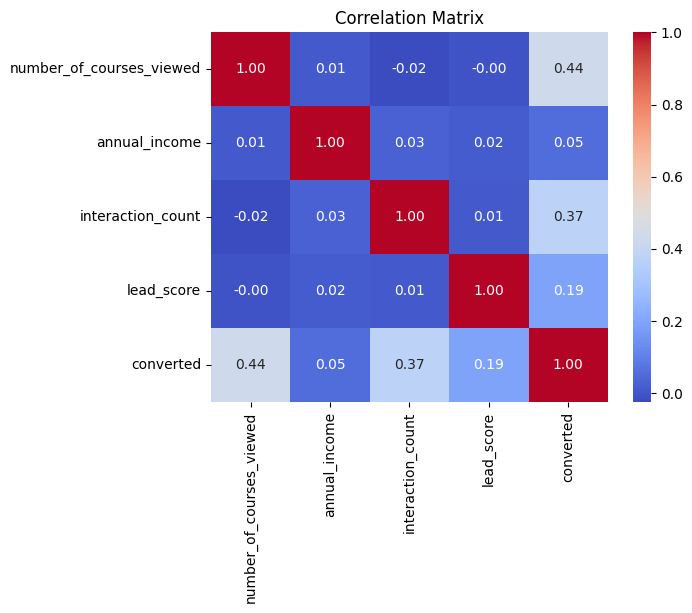

In [219]:
corr_matrix = df[num_cols].corr()

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Split the data

- Split your data in train/val/test sets with 60%/20%/20% distribution.
- Use Scikit-Learn for that (the `train_test_split` function) and set the seed to `42`.
- Make sure that the target value `converted` is not in your dataframe.

In [220]:
from sklearn.model_selection import train_test_split

In [221]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
print(f"Full train set: {len(df_full_train):,}")
print(f"Test set:       {len(df_test):,}")

Full train set: 1,169
Test set:       293


In [222]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1) # note that 20%/80% = 25%

In [223]:
print("\nAfter second split:")
print(f"Train set:      {len(df_train):,}")
print(f"Validation set: {len(df_val):,}")
print(f"Test set:       {len(df_test):,}")


After second split:
Train set:      876
Validation set: 293
Test set:       293


In [224]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test[ 'converted']

## Question 3

- Calculate the mutual information score between `converted` and other categorical variables in the dataset. Use the training set only.
- Round the scores to 2 decimals using `round(score, 2)`.

Which of these variables has the biggest mutual information score?

- `industry`
- `location`
- `lead_source`
- `employment_status`


In [225]:
from sklearn.metrics import mutual_info_score

def mutual_info_converted_score(series):
  return mutual_info_score(series, df_full_train.converted)

mi = df_full_train[cat_cols].apply(mutual_info_converted_score)
mi.sort_values(ascending=False)

,0
lead_source,0.025665
employment_status,0.013258
industry,0.011685
location,0.002253


## Question 4

- Now let's train a logistic regression.
- Remember that we have several categorical variables in the dataset. Include them using one-hot encoding.
- Fit the model on the training dataset.
  - To make sure the results are reproducible across different versions of Scikit-Learn, fit the model with these parameters:
  - `model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)`
- Calculate the accuracy on the validation dataset and round it to 2 decimal digits.

What accuracy did you get?

- 0.64
- 0.74
- 0.84
- 0.94

#### One-Hot Encoding

In [226]:
df_train.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score
1406,organic_search,retail,1,0.0,student,asia,4,0.47
701,referral,education,1,68218.0,self_employed,asia,2,0.37
336,NA,manufacturing,1,50616.0,unemployed,europe,5,0.63
976,organic_search,technology,2,58172.0,student,asia,4,0.45
215,organic_search,education,3,62120.0,student,europe,6,0.95


In [227]:
from sklearn.feature_extraction import DictVectorizer

train_dicts = df_train.to_dict(orient='records')
val_dicts = df_val.to_dict(orient='records')

train_dicts[0] # to see what it look like

{'lead_source': 'organic_search',
 'industry': 'retail',
 'number_of_courses_viewed': 1,
 'annual_income': 0.0,
 'employment_status': 'student',
 'location': 'asia',
 'interaction_count': 4,
 'lead_score': 0.47}

In [228]:
dv = DictVectorizer(sparse=False)
dv.fit(train_dicts)

DictVectorizer(sparse=False)

In [229]:
X_train = dv.transform(train_dicts)
X_val   = dv.transform(val_dicts)

### Training the Model

In [230]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)

In [231]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [232]:
model.coef_.round(3)

array([[-0.   , -0.014,  0.073, -0.005, -0.004, -0.27 , -0.075,  0.106,
        -0.069, -0.031, -0.02 , -0.039, -0.058, -0.035,  0.419,  0.077,
         0.004, -0.062, -0.031, -0.229,  0.138, -0.041,  0.004, -0.05 ,
        -0.033, -0.005, -0.016, -0.006, -0.063, -0.052,  0.738]])

In [233]:
y_pred = model.predict_proba(X_val)[:, 1]
convert_decision = (y_pred >= 0.5)
convert_decision.astype(int)

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1])

In [234]:
(y_val == convert_decision).mean()

np.float64(0.7440273037542662)

## Question 5

- Let's find the least useful feature using the _feature elimination_ technique.
- Train a model using the same features and parameters as in Q4 (without rounding).
- Now exclude each feature from this set and train a model without it. Record the accuracy for each model.
- For each feature, calculate the difference between the original accuracy and the accuracy without the feature.

Which of following feature has the smallest difference?

- `'industry'`
- `'employment_status'`
- `'lead_score'`

> **Note**: The difference doesn't have to be positive.

In [235]:
df_train.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score
1406,organic_search,retail,1,0.0,student,asia,4,0.47
701,referral,education,1,68218.0,self_employed,asia,2,0.37
336,NA,manufacturing,1,50616.0,unemployed,europe,5,0.63
976,organic_search,technology,2,58172.0,student,asia,4,0.45
215,organic_search,education,3,62120.0,student,europe,6,0.95


In [236]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Original accuracy from Question 4
original_accuracy = (y_val == convert_decision).mean()

features_to_eliminate = ['industry', 'employment_status', 'lead_score']
accuracy_differences = {}

for feature in features_to_eliminate:
    # Create a copy of the training and validation dataframes
    df_train_subset = df_train.copy()
    df_val_subset = df_val.copy()

    # Drop the current feature
    if feature in df_train_subset.columns:
        df_train_subset = df_train_subset.drop(columns=[feature])
    if feature in df_val_subset.columns:
        df_val_subset = df_val_subset.drop(columns=[feature])

    # One-hot encode the subset data
    train_dicts_subset = df_train_subset.to_dict(orient='records')
    val_dicts_subset = df_val_subset.to_dict(orient='records')

    dv_subset = DictVectorizer(sparse=False)
    X_train_subset = dv_subset.fit_transform(train_dicts_subset)
    X_val_subset = dv_subset.transform(val_dicts_subset)

    # Train the model without the feature
    model_subset = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
    model_subset.fit(X_train_subset, y_train)

    # Calculate accuracy on the validation set
    y_pred_subset = model_subset.predict_proba(X_val_subset)[:, 1]
    convert_decision_subset = (y_pred_subset >= 0.5)
    accuracy_subset = accuracy_score(y_val, convert_decision_subset)

    # Calculate the difference in accuracy
    accuracy_differences[feature] = original_accuracy - accuracy_subset

# Find the feature with the smallest absolute difference
least_useful_feature = min(accuracy_differences, key=lambda k: abs(accuracy_differences[k]))

print("Accuracy differences after removing each feature:")
for feature, diff in accuracy_differences.items():
    print(f"- {feature}: {diff:.4f}")

print(f"\nThe feature with the smallest absolute difference (least useful) is: '{least_useful_feature}'")

Accuracy differences after removing each feature:
- industry: 0.0102
- employment_status: -0.0512
- lead_score: 0.0034

The feature with the smallest absolute difference (least useful) is: 'lead_score'


## Question 6

- Now let's train a regularized logistic regression.
- Let's try the following values of the parameter `C`: `[0.01, 0.1, 1, 10, 100]`.
- Train models using all the features as in Q4.
- Calculate the accuracy on the validation dataset and round it to 3 decimal digits.

Which of these `C` leads to the best accuracy on the validation set?

- 0.01
- 0.1
- 1
- 10
- 100

> **Note**: If there are multiple options, select the smallest `C`.

In [247]:
c_values = [0.01, 0.1, 1, 10, 100]
best_accuracy = -1
best_c = -1
accuracies = {}

for c in c_values:
  model = LogisticRegression(solver='liblinear', C=c, max_iter=1000, random_state=42)
  model.fit(X_train, y_train)

  y_pred = model.predict_proba(X_val)[:, 1]
  convert_decision = (y_pred >= 0.5)
  accuracy = accuracy_score(y_val, convert_decision)

  accuracies[c] = accuracy

  if accuracy > best_accuracy:
    best_accuracy = accuracy
    best_c = c
  # If accuracies are equal, choose the smaller C as per the note
  elif accuracy == best_accuracy and c < best_c:
    best_c = c

print("Accuracy for different C values:")
for c, accuracy in accuracies.items():
    print(f"C={c}: {accuracy}")

print(f"\nBest C value: {best_c} with accuracy: {best_accuracy}")

Accuracy for different C values:
C=0.01: 0.7440273037542662
C=0.1: 0.7440273037542662
C=1: 0.7440273037542662
C=10: 0.7440273037542662
C=100: 0.7440273037542662

Best C value: 0.01 with accuracy: 0.7440273037542662


it's weird that we're getting the same accuracy for different values of `c`.

Below is code to check that our model is changing, we look into it's coefficients

In [249]:
from sklearn.linear_model import LogisticRegression

c_values = [0.01, 0.1, 1, 10, 100]
models = {}

print("Model Coefficients for different C values:")
for c in c_values:
    model = LogisticRegression(solver='liblinear', C=c, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    models[c] = model # Store the fitted model

    # Display coefficients (rounded for readability)
    print(f"\nC={c}:")
    # We need to get the feature names from the DictVectorizer
    feature_names = dv.get_feature_names_out()
    coefficients = dict(zip(feature_names, model.coef_[0].round(4)))
    print(coefficients)

Model Coefficients for different C values:

C=0.01:
{'annual_income': np.float64(-0.0), 'employment_status=NA': np.float64(-0.011), 'employment_status=employed': np.float64(0.0524), 'employment_status=self_employed': np.float64(-0.0032), 'employment_status=student': np.float64(-0.0021), 'employment_status=unemployed': np.float64(-0.1941), 'industry=NA': np.float64(-0.0539), 'industry=education': np.float64(0.0781), 'industry=finance': np.float64(-0.0491), 'industry=healthcare': np.float64(-0.0219), 'industry=manufacturing': np.float64(-0.0141), 'industry=other': np.float64(-0.0283), 'industry=retail': np.float64(-0.044), 'industry=technology': np.float64(-0.0249), 'interaction_count': np.float64(0.3712), 'lead_score': np.float64(0.0604), 'lead_source=NA': np.float64(0.0036), 'lead_source=events': np.float64(-0.0445), 'lead_source=organic_search': np.float64(-0.0216), 'lead_source=paid_ads': np.float64(-0.1661), 'lead_source=referral': np.float64(0.1017), 'lead_source=social_media': np.